# In-band behaviour of the voice coil actuator, 35 to 55 Hz, from the existing logs

**Goal.** The application needs the mass to oscillate between 35 and 55 Hz. This notebook asks what the
runs we already have say about that band, before any new experiment is designed. It uses only the part of
each log where the excitation is inside the band.

**What existing data can answer**

* how strong the in-band position and acceleration signals are compared with the noise, via coherence
* the frequency response from current to position, current to acceleration and target current to actual current
* the motor constant $K_f$ implied by each sensor in the band, and whether the two sensors agree
* whether the drive's current loop is transparent in the band

**What existing data cannot answer**

* the true noise floor of the sensors, because none of these runs has a quiet zero-current window (logs
  recorded since the firmware added the 0 A bias idle window do, and section 7 uses it when present)
* linearity with current beyond the 5 A versus 6.5 A comparison that the three chirps allow
* anything at a displaced operating point, because all runs oscillate around the centre

**Physics of the band.** Above 20 Hz the mover is on the mass line, so position per amp is
$K_f/(m\omega^2)$. The small-signal stiffness found in the main notebook, 35 kN/m, contributes well under
1 percent of the inertial force here, so the spring is ignored throughout and a pure mass is the reference.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import least_squares

import vca_log               # shared log loader: old and new (bias idle window) formats

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

FS = 2000.0                  # Hz
M = 51.5                     # kg, moving mass
G = 9.81
KF_DATASHEET = 283.0         # N/A
KF_PHASE2 = 256.2            # N/A, tail fit of the main notebook (laser based)
ACC_SCALE_V_PER_G = 0.0578   # accelerometer, as in the main notebook
LASER_R_SHUNT = 476.0        # ohm, laser 4 to 20 mA shunt
LASER_V_MIN = 4e-3 * LASER_R_SHUNT * 1.02

F_BAND = (33.0, 55.0)        # Hz, analysis band with a little margin below 35 Hz
F_MAINS = 50.0               # Hz, mains pickup sits here in both sensor channels
NPERSEG = 2048               # Welch segment, about 1 Hz resolution at 2 kHz

# The runs. Chirp runs are logarithmic 1 Hz to f1 over 120 s; the PRBS run is broadband up to 55 Hz.
RUNS = {
    "chirp 6.5 A run 1": dict(path="data/voice_coil_log_chirp_6.5A_1.0to55.0Hz_120.0s_20260923_160540.csv", f0=1.0, f1=55.0),
    "chirp 6.5 A run 2": dict(path="data/voice_coil_log_chirp_6.5A_1.0to55.0Hz_120.0s_20260923_155557.csv", f0=1.0, f1=55.0),
    "chirp 5.0 A":       dict(path="data/voice_coil_log_chirp_5.0A_1.0to50.0Hz_120.0s_20260923_151818.csv", f0=1.0, f1=50.0),
    "prbs 5.0 A":        dict(path="data/voice_coil_log_prbs_5.0A_55.0Hz_120.0s_20260923_165315.csv", f0=None, f1=None),
}
T_CHIRP = 120.0

def time_at_freq(f, f0, f1):
    "Time at which a logarithmic chirp from f0 to f1 over T_CHIRP passes frequency f."
    return T_CHIRP * np.log(f / f0) / np.log(f1 / f0)

## 1. Load the runs and keep only the in-band part

For a chirp the band starts at the moment the instantaneous frequency passes 33 Hz, which is the last
13 to 15 s of the run. The PRBS run excites the whole band all the time, so all 120 s are used. Note that
the PRBS run also carries large low-frequency motion, so the mover swings through most of the stroke while
the chirp tails stay within a few millimetres of the centre. That difference matters later.

The laser range check from the main notebook is repeated here. In the chirp tails the laser is always in
range, so no masking is needed.

In [2]:
def load_run(path):
    "Load a log with vca_log: duplicate first row dropped, accelerometer bias removed in ai2_corrected_V."
    return vca_log.load_log(path)

logs = {}
segs = {}
rows = []
for name, spec in RUNS.items():
    log = load_run(spec["path"])
    logs[name] = log
    raw = log.run                                        # t >= 0 only, so a 0 A idle window never enters the band
    t = raw["time_s"].to_numpy()
    if spec["f0"] is not None:
        in_band = t >= time_at_freq(F_BAND[0], spec["f0"], spec["f1"])
        f_top = spec["f1"]
    else:
        in_band = np.ones(len(raw), dtype=bool)
        f_top = 55.0
    s = pd.DataFrame({
        "t":      t[in_band],
        "i":      raw["actual_current_A"].to_numpy()[in_band],
        "i_tgt":  raw["target_current_A"].to_numpy()[in_band],
        "x":      raw["position_mm"].to_numpy()[in_band] * 1e-3,                       # m
        "a":      raw["ai2_corrected_V"].to_numpy()[in_band] / ACC_SCALE_V_PER_G * G,  # m/s^2, bias removed
        "laser_ok": raw["ai1_value_V"].to_numpy()[in_band] >= LASER_V_MIN,
    })
    s.attrs["f_top"] = f_top
    segs[name] = s
    rows.append((name, log.bias_source, len(s) / FS, 100 * s.laser_ok.mean(), s.x.std() * 1e3, s.i.std(), s.a.std() / G))
pd.DataFrame(rows, columns=["run", "bias source", "seconds in band", "laser in range %", "x rms (mm)", "i rms (A)", "a rms (g)"]).round(3)

,run,seconds in band,laser in range %,x rms (mm),i rms (A),a rms (g)
0,chirp 6.5 A run 1,15.296,100.000,0.452,4.003,1.514
1,chirp 6.5 A run 2,15.296,100.000,0.496,4.000,1.515
2,chirp 5.0 A,12.746,100.000,0.381,3.044,1.176
3,prbs 5.0 A,120.000,99.188,8.482,4.382,1.380


**Accelerometer bias per run.** The accelerometer offset shifts from run to run. Newer logs measure it in a
3 s window at 0 A before the excitation; older logs fall back to the whole-run mean (see
`docs/accelerometer-bias.md`). The table shows the bias that was removed, where it came from, and the
accelerometer noise in the idle window when there is one.

In [ ]:
vca_log.bias_report(logs, ACC_SCALE_V_PER_G).round(4)

## 2. What the signals look like in the band

Amplitude spectra of current, position and acceleration over 30 to 60 Hz for each run. The chirp tails
show a flat current amplitude with a position amplitude that falls as $1/f^2$, which is the mass line.
The dotted line marks 50 Hz mains. It is visible in both sensor channels and is not motion.

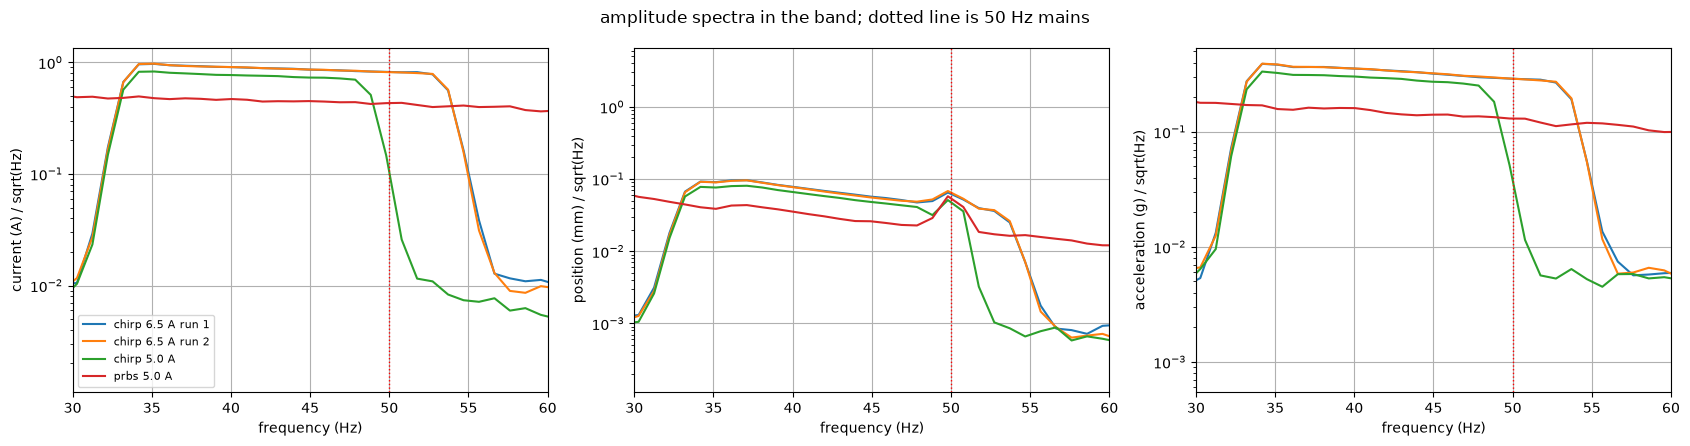

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for name, s in segs.items():
    for a_, sig_, lab in [(ax[0], s.i.to_numpy(), "current (A)"), (ax[1], s.x.to_numpy() * 1e3, "position (mm)"), (ax[2], s.a.to_numpy() / G, "acceleration (g)")]:
        f, P = signal.welch(sig_ - sig_.mean(), FS, nperseg=NPERSEG)
        a_.semilogy(f, np.sqrt(P), label=name)
        a_.set_xlim(30, 60); a_.set_xlabel("frequency (Hz)"); a_.set_ylabel(lab + " / sqrt(Hz)")
for a_ in ax:
    a_.axvline(F_MAINS, color="r", ls=":", lw=1)
ax[0].legend(fontsize=8)
fig.suptitle("amplitude spectra in the band; dotted line is 50 Hz mains")
plt.tight_layout(); plt.show()

## 3. Frequency responses with coherence

Three transfer functions per run, estimated with Welch's method (cross spectrum divided by input
spectrum) and shown with their coherence:

* **current to position**, compared with the mass line $K_f/(m\omega^2)$ for the datasheet and the Phase 2 motor constant
* **current to acceleration** from the accelerometer, compared with the constant $K_f/m$
* **target current to actual current**, which is the drive's current loop as seen over EtherCAT

Coherence close to 1 means the output at that frequency is explained by the input, so the estimate is
signal and not noise. Where coherence drops, the transfer function value at that frequency should not be
trusted. Expect a drop at 50 Hz in the laser channel.

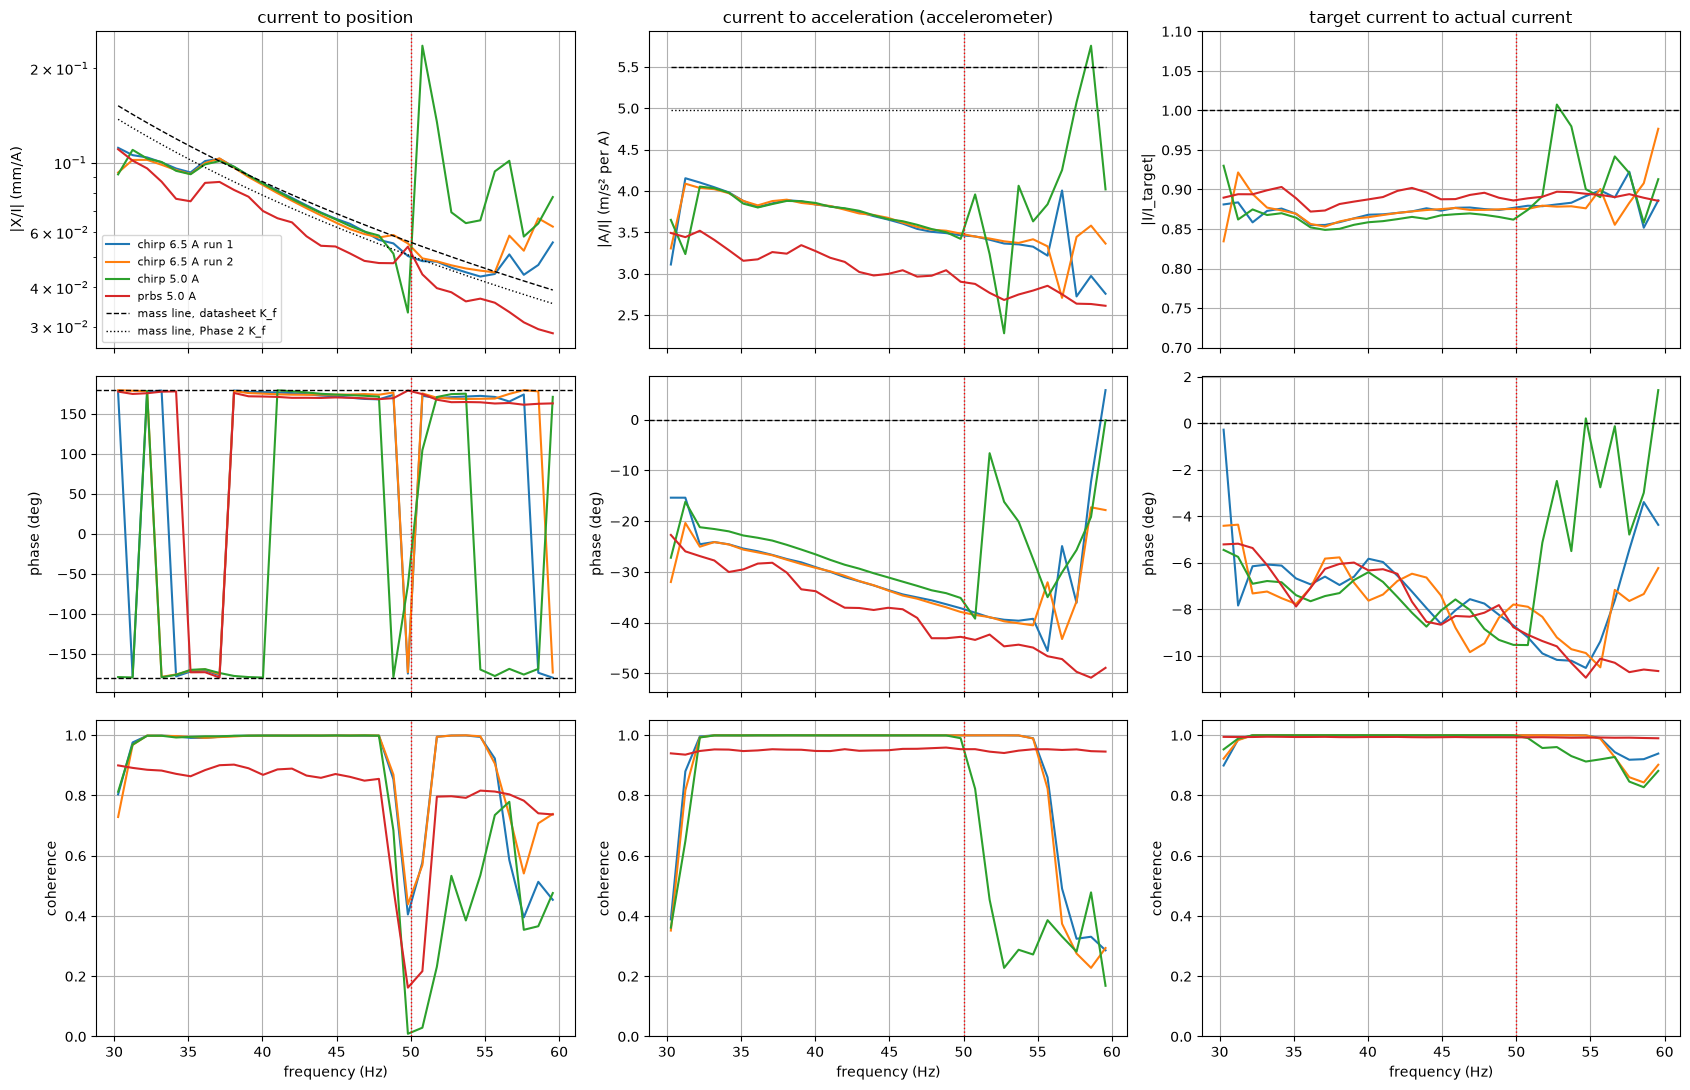

In [4]:
def frf(u, y):
    "H1 estimate of y/u with coherence, on the common Welch grid."
    f, Puu = signal.welch(u, FS, nperseg=NPERSEG)
    _, Puy = signal.csd(u, y, FS, nperseg=NPERSEG)
    _, coh = signal.coherence(u, y, FS, nperseg=NPERSEG)
    return f, Puy / Puu, coh

FRF = {}
for name, s in segs.items():
    f, Hx, cx = frf(s.i.to_numpy(), s.x.to_numpy())
    _, Ha, ca = frf(s.i.to_numpy(), s.a.to_numpy())
    _, Hi, ci = frf(s.i_tgt.to_numpy(), s.i.to_numpy())
    FRF[name] = dict(f=f, Hx=Hx, cx=cx, Ha=Ha, ca=ca, Hi=Hi, ci=ci)

w = 2 * np.pi * f
band = (f >= 30) & (f <= 60)

fig, ax = plt.subplots(3, 3, figsize=(17, 11), sharex=True)
for name, R in FRF.items():
    ax[0, 0].semilogy(f[band], np.abs(R["Hx"][band]) * 1e3, label=name)
    ax[1, 0].plot(f[band], np.degrees(np.angle(R["Hx"][band])))
    ax[2, 0].plot(f[band], R["cx"][band])
    ax[0, 1].plot(f[band], np.abs(R["Ha"][band]))
    ax[1, 1].plot(f[band], np.degrees(np.angle(R["Ha"][band])))
    ax[2, 1].plot(f[band], R["ca"][band])
    ax[0, 2].plot(f[band], np.abs(R["Hi"][band]))
    ax[1, 2].plot(f[band], np.degrees(np.angle(R["Hi"][band])))
    ax[2, 2].plot(f[band], R["ci"][band])
for kf, lab, ls in [(KF_DATASHEET, "mass line, datasheet K_f", "k--"), (KF_PHASE2, "mass line, Phase 2 K_f", "k:")]:
    ax[0, 0].semilogy(f[band], kf / (M * w[band] ** 2) * 1e3, ls, lw=1, label=lab)
    ax[0, 1].plot(f[band], np.full(band.sum(), kf / M), ls, lw=1)
ax[1, 0].axhline(-180, color="k", ls="--", lw=1); ax[1, 0].axhline(180, color="k", ls="--", lw=1)
ax[1, 1].axhline(0, color="k", ls="--", lw=1); ax[0, 2].axhline(1, color="k", ls="--", lw=1); ax[1, 2].axhline(0, color="k", ls="--", lw=1)
ax[0, 0].set_title("current to position"); ax[0, 0].set_ylabel("|X/I| (mm/A)"); ax[0, 0].legend(fontsize=8)
ax[0, 1].set_title("current to acceleration (accelerometer)"); ax[0, 1].set_ylabel("|A/I| (m/s² per A)")
ax[0, 2].set_title("target current to actual current"); ax[0, 2].set_ylabel("|I/I_target|"); ax[0, 2].set_ylim(0.7, 1.1)
for k_ in range(3):
    ax[1, k_].set_ylabel("phase (deg)"); ax[2, k_].set_ylabel("coherence"); ax[2, k_].set_ylim(0, 1.05); ax[2, k_].set_xlabel("frequency (Hz)")
    for r_ in range(3):
        ax[r_, k_].axvline(F_MAINS, color="r", ls=":", lw=1)
plt.tight_layout(); plt.show()

**How to read this.**

* Position per amp should sit on one of the mass lines and fall smoothly with frequency. A bump or dip
  that repeats across runs is real dynamics, for example a structural mode between the coil and the laser
  target.
* Position phase should be near $-180°$ (shown as $\pm180°$). A few degrees beyond $-180°$ is a delay in the
  laser path relative to the current; at 45 Hz, one degree is about 62 µs.
* Acceleration per amp should be flat at $K_f/m$ with zero phase. A value that falls with frequency while
  the phase grows negative is a low pass somewhere in the accelerometer chain.
* The current loop should be 1 with zero phase. A flat gain below 1 with small phase is not a bandwidth
  limit but a steady gain error, which matters for how much force a given demand really produces.

## 4. Motor constant implied by each sensor

On a pure mass line, the laser gives $K_f = m\,\omega^2\,|X/I|$ and the accelerometer gives $K_f = m\,|A/I|$.
The table lists both at five frequencies for every run. Values at 50 Hz from the laser are shown but the
coherence there is low, so they carry little weight.

              run  f_Hz  Kf_laser  coh_laser  Kf_accel  coh_accel
chirp 6.5 A run 1    35    233.81       0.99    199.80       1.00
chirp 6.5 A run 1    40    279.77       1.00    197.58       1.00
chirp 6.5 A run 1    45    271.86       1.00    188.19       1.00
chirp 6.5 A run 1    50    253.95       0.41    178.42       1.00
chirp 6.5 A run 2    35    231.16       0.99    199.83       1.00
chirp 6.5 A run 2    40    276.35       1.00    197.60       1.00
chirp 6.5 A run 2    45    264.54       1.00    189.26       1.00
chirp 6.5 A run 2    50    278.57       0.44    179.45       1.00
      chirp 5.0 A    35    230.77       0.99    198.14       1.00
      chirp 5.0 A    40    279.23       1.00    198.53       1.00
      chirp 5.0 A    45    270.60       1.00    188.46       1.00
       prbs 5.0 A    35    189.17       0.86    162.54       0.95
       prbs 5.0 A    40    228.43       0.87    168.52       0.95
       prbs 5.0 A    45    221.60       0.87    154.35       0.95
       prb

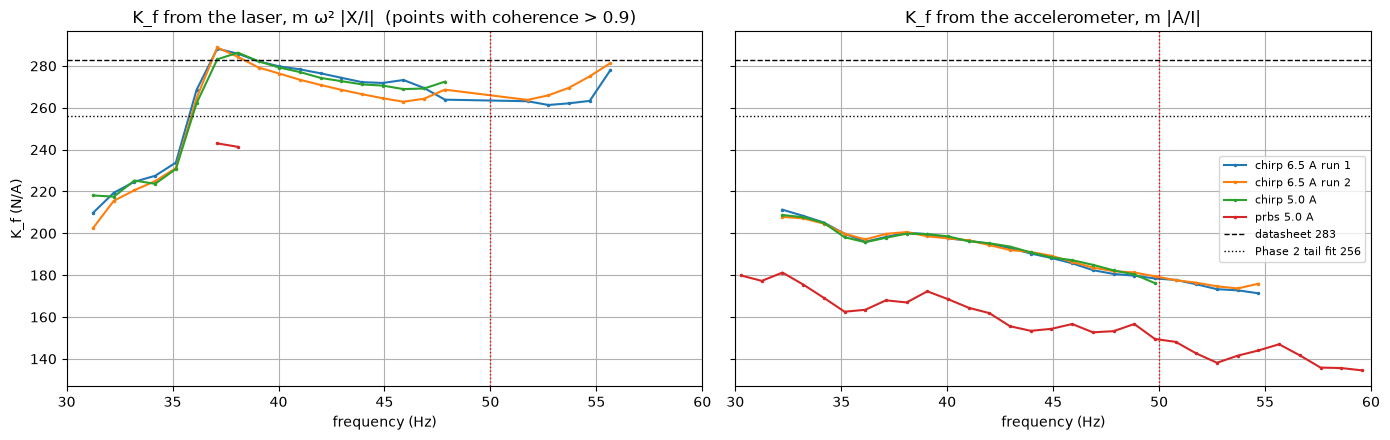

In [5]:
F_EVAL = [35, 40, 45, 50, 55]
rows = []
for name, R in FRF.items():
    f_top = segs[name].attrs["f_top"]
    for fe in F_EVAL:
        if fe > f_top - 1:
            continue
        k = np.argmin(np.abs(f - fe))
        rows.append(dict(run=name, f_Hz=fe,
                         Kf_laser=M * w[k] ** 2 * np.abs(R["Hx"][k]), coh_laser=R["cx"][k],
                         Kf_accel=M * np.abs(R["Ha"][k]), coh_accel=R["ca"][k]))
kf_table = pd.DataFrame(rows)
print(kf_table.round(2).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for name, R in FRF.items():
    ok = band & (R["cx"] > 0.9)
    ax[0].plot(f[ok], M * w[ok] ** 2 * np.abs(R["Hx"][ok]), ".-", ms=3, label=name)
    ok = band & (R["ca"] > 0.9)
    ax[1].plot(f[ok], M * np.abs(R["Ha"][ok]), ".-", ms=3, label=name)
for a_ in ax:
    a_.axhline(KF_DATASHEET, color="k", ls="--", lw=1, label="datasheet 283")
    a_.axhline(KF_PHASE2, color="k", ls=":", lw=1, label="Phase 2 tail fit 256")
    a_.axvline(F_MAINS, color="r", ls=":", lw=1); a_.set_xlabel("frequency (Hz)"); a_.set_xlim(30, 60)
ax[0].set_ylabel("K_f (N/A)"); ax[0].set_title("K_f from the laser, m ω² |X/I|  (points with coherence > 0.9)")
ax[1].set_title("K_f from the accelerometer, m |A/I|"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**A feature near 35 Hz.** The laser-implied $K_f$ is not smooth: it dips around 34 to 35 Hz and jumps
back up at 36 to 37 Hz. The cell below looks at this with finer frequency resolution, using the chirp from
22 Hz onward so the feature is seen with clean data on both sides, and puts the accelerometer next to it.
A dip followed by a peak, with a phase wobble, is the signature of a lightly damped mechanical mode. If
the accelerometer does not show it at the same frequency, the mode is in something the laser sees and the
accelerometer does not: the laser bracket, the surface it aims at, or the frame the laser is mounted on.

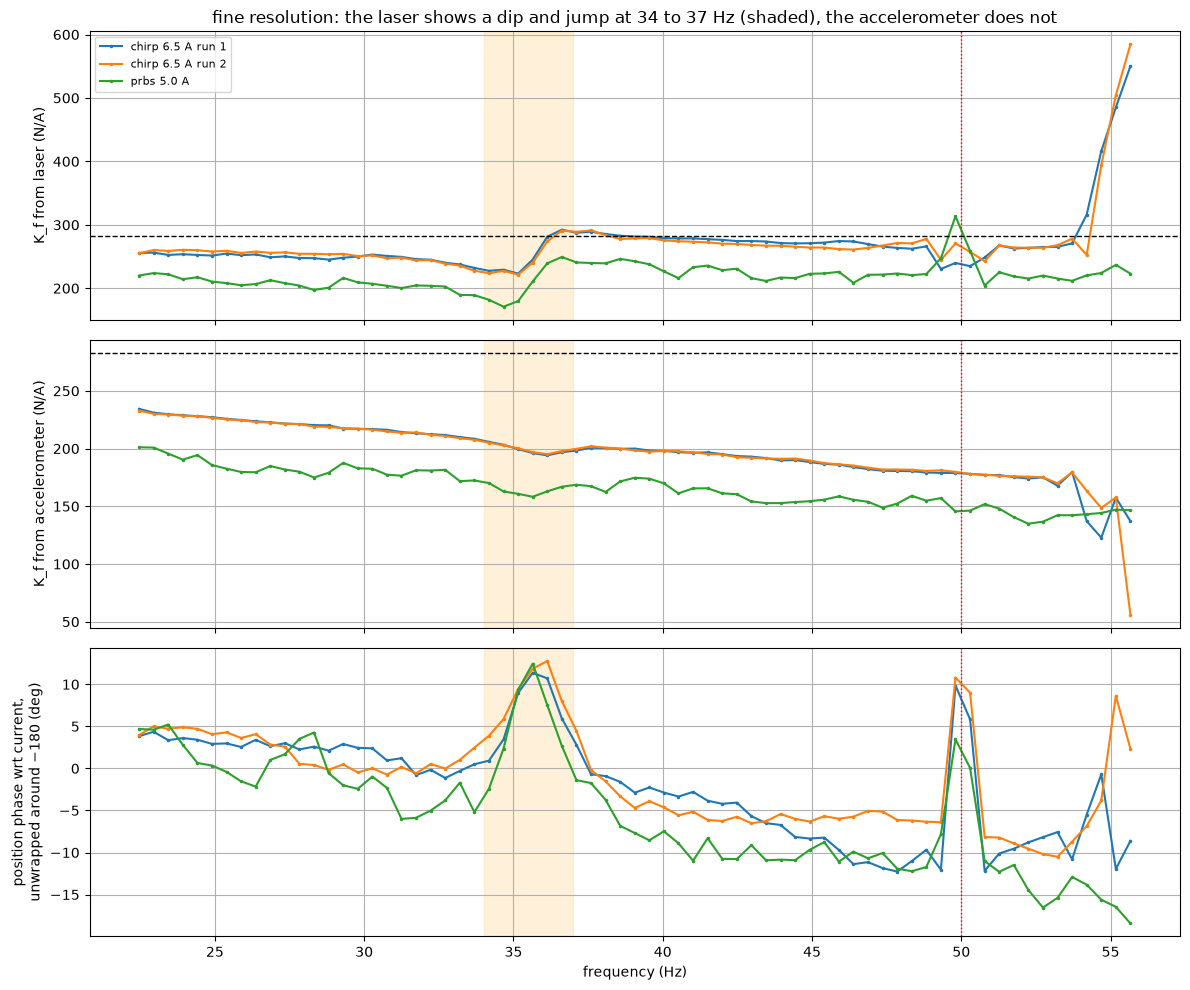

In [6]:
# Finer resolution (about 0.5 Hz) from 22 Hz onward. The chirp passes 22 Hz at t = 92 s, so this uses the
# last 28 s of the 6.5 A run. The PRBS run is included because it excites all frequencies at once, so a
# feature that appears at the same frequency in both is mechanical and not an artefact of the sweep.
NPERSEG_FINE = 4096
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for name in ["chirp 6.5 A run 1", "chirp 6.5 A run 2", "prbs 5.0 A"]:
    raw = load_run(RUNS[name]["path"]).run
    t = raw["time_s"].to_numpy()
    sel = t >= (time_at_freq(22.0, RUNS[name]["f0"], RUNS[name]["f1"]) if RUNS[name]["f0"] else 0.0)
    i_ = raw["actual_current_A"].to_numpy()[sel]
    x_ = raw["position_mm"].to_numpy()[sel] * 1e-3
    a_ = raw["ai2_corrected_V"].to_numpy()[sel] / ACC_SCALE_V_PER_G * G
    ff, Pii = signal.welch(i_, FS, nperseg=NPERSEG_FINE)
    _, Pxi = signal.csd(i_, x_, FS, nperseg=NPERSEG_FINE); _, cxi = signal.coherence(i_, x_, FS, nperseg=NPERSEG_FINE)
    _, Pai = signal.csd(i_, a_, FS, nperseg=NPERSEG_FINE)
    ww = 2 * np.pi * ff
    zoom = (ff >= 22) & (ff <= 56)
    ln, = ax[0].plot(ff[zoom], M * ww[zoom] ** 2 * np.abs(Pxi / Pii)[zoom], ".-", ms=3, label=name)
    ax[1].plot(ff[zoom], M * np.abs(Pai / Pii)[zoom], ".-", ms=3, color=ln.get_color())
    ax[2].plot(ff[zoom], np.degrees(np.angle(Pxi / Pii))[zoom] % 360 - 180, ".-", ms=3, color=ln.get_color())
for a_ in ax:
    a_.axvline(F_MAINS, color="r", ls=":", lw=1); a_.axvspan(34, 37, color="orange", alpha=0.15)
ax[0].axhline(KF_DATASHEET, color="k", ls="--", lw=1); ax[0].set_ylabel("K_f from laser (N/A)"); ax[0].legend(fontsize=8)
ax[0].set_title("fine resolution: the laser shows a dip and jump at 34 to 37 Hz (shaded), the accelerometer does not")
ax[1].axhline(KF_DATASHEET, color="k", ls="--", lw=1); ax[1].set_ylabel("K_f from accelerometer (N/A)")
ax[2].set_ylabel("position phase wrt current,\nunwrapped around −180 (deg)"); ax[2].set_xlabel("frequency (Hz)")
plt.tight_layout(); plt.show()

**Two things to notice.** The three chirp tails agree with each other to a few percent at every frequency,
so the in-band measurement is repeatable and the 5 A versus 6.5 A comparison shows no amplitude dependence
at this level. The PRBS run gives lower values from both sensors. During the PRBS the mover swings across
most of the stroke, and the main notebook's model C found that $K_f$ falls by roughly 16 percent at 10 mm
from centre. A lower average $K_f$ over a wide swing is what that predicts. The chirp tails, which stay
within a few millimetres of centre, are the relevant case for the application.

The laser and the accelerometer do not agree with each other, and that disagreement is the subject of the
next section.

## 5. Laser against accelerometer, frequency by frequency

The ratio of the accelerometer's $A/I$ to the laser's $-\omega^2 X/I$ isolates the two sensor chains from
the actuator. Any actuator physics cancels, because both sensors see the same motion. What remains is
scale, delay and filtering in the two chains, plus any mechanical compliance between the two measurement
points.

Two simple explanations are fitted to the ratio over the band, leaving out the mains-contaminated bins:

1. **gain and pure delay**: $g\,e^{-j\omega\tau}$, magnitude flat, phase a straight line
2. **first order low pass**: $g/(1 + j f/f_c)$, magnitude falling, phase curving towards $-90°$

Whichever fits with the smaller residual says what kind of thing sits in the accelerometer chain. Both
fits include the gain $g$ because the main notebook already found a scale difference of about 0.73 over the
whole run.

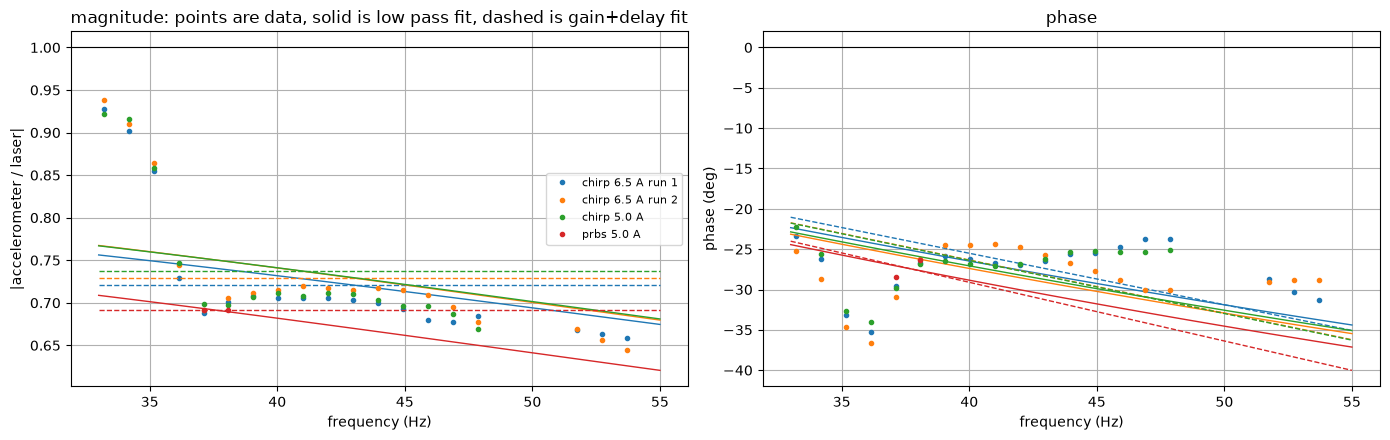

              run  gain (delay model)  delay (ms)  rms resid delay  gain (low pass model)  fc (Hz)  rms resid low pass
chirp 6.5 A run 1               0.721       1.771            0.071                  0.818   80.330               0.062
chirp 6.5 A run 2               0.729       1.829            0.074                  0.835   77.203               0.064
      chirp 5.0 A               0.737       1.832            0.071                  0.832   78.283               0.063
       prbs 5.0 A               0.691       2.021            0.012                  0.778   72.630               0.012


In [7]:
def fit_models(f_pts, ratio):
    "Fit gain+delay and first order low pass to a complex ratio; return parameters and rms residuals."
    def res_delay(p):
        g, tau = p
        m = g * np.exp(-2j * np.pi * f_pts * tau)
        return np.r_[(m - ratio).real, (m - ratio).imag]
    def res_lp(p):
        g, fc = p
        m = g / (1 + 1j * f_pts / fc)
        return np.r_[(m - ratio).real, (m - ratio).imag]
    r1 = least_squares(res_delay, [0.8, 2e-3])
    r2 = least_squares(res_lp, [1.0, 50.0])
    rms = lambda r: np.sqrt(np.mean(r.fun ** 2))
    return r1.x, rms(r1), r2.x, rms(r2)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
rows = []
for name, R in FRF.items():
    f_top = segs[name].attrs["f_top"]
    with np.errstate(divide="ignore", invalid="ignore"):      # the 0 Hz bin divides by zero and is never used
        ratio = R["Ha"] / (-w ** 2 * R["Hx"])
    use = (f >= F_BAND[0]) & (f <= min(F_BAND[1], f_top - 1)) & (np.abs(f - F_MAINS) > 1.5) & (R["cx"] > 0.9) & (R["ca"] > 0.9)
    (g1, tau), e1, (g2, fc), e2 = fit_models(f[use], ratio[use])
    rows.append((name, g1, tau * 1e3, e1, g2, fc, e2))
    ln, = ax[0].plot(f[use], np.abs(ratio[use]), "o", ms=3, label=name)
    ax[1].plot(f[use], np.degrees(np.angle(ratio[use])), "o", ms=3, color=ln.get_color())
    fg = np.linspace(F_BAND[0], F_BAND[1], 100)
    ax[0].plot(fg, np.abs(g2 / (1 + 1j * fg / fc)), "-", lw=1, color=ln.get_color())
    ax[1].plot(fg, np.degrees(np.angle(g2 / (1 + 1j * fg / fc))), "-", lw=1, color=ln.get_color())
    ax[0].plot(fg, np.full_like(fg, g1), "--", lw=1, color=ln.get_color())
    ax[1].plot(fg, -360 * fg * tau, "--", lw=1, color=ln.get_color())
ax[0].axhline(1, color="k", lw=0.8); ax[1].axhline(0, color="k", lw=0.8)
ax[0].set_ylabel("|accelerometer / laser|"); ax[0].set_xlabel("frequency (Hz)"); ax[0].set_title("magnitude: points are data, solid is low pass fit, dashed is gain+delay fit")
ax[1].set_ylabel("phase (deg)"); ax[1].set_xlabel("frequency (Hz)"); ax[1].set_title("phase")
ax[0].legend(fontsize=8); plt.tight_layout(); plt.show()

fits = pd.DataFrame(rows, columns=["run", "gain (delay model)", "delay (ms)", "rms resid delay", "gain (low pass model)", "fc (Hz)", "rms resid low pass"])
print(fits.round(3).to_string(index=False))

**What to conclude from the fit.** If the low pass model wins clearly, the accelerometer chain rolls off
inside the band, most likely an output filter in the sensor or an input filter on the drive's analog
channel, and the laser is the sensor to trust for magnitude in this band. If the gain and delay model wins,
one chain is simply late and scaled, and a static tilt test of the accelerometer decides which scale is
right. If neither fits well, look for mechanical compliance between the laser target and the accelerometer
mount, which would show as a resonance shape rather than a smooth roll-off.

Either way, the accelerometer cannot be used for in-band force estimates until this is resolved, and any
control loop that closes on the accelerometer at 35 to 55 Hz inherits this phase lag.

## 6. The current loop in the band

The transfer function from target current to actual current is what the drive does between the demand
sent over EtherCAT and the current it reports back. Both are drive-side numbers, so this also includes any
filtering the drive applies to its reported current. Values at the five evaluation frequencies:

In [8]:
rows = []
for name, R in FRF.items():
    f_top = segs[name].attrs["f_top"]
    for fe in F_EVAL:
        if fe > f_top - 1:
            continue
        k = np.argmin(np.abs(f - fe))
        rows.append(dict(run=name, f_Hz=fe, gain=np.abs(R["Hi"][k]), phase_deg=np.degrees(np.angle(R["Hi"][k])),
                         delay_equiv_ms=-np.degrees(np.angle(R["Hi"][k])) / 360 / fe * 1e3, coherence=R["ci"][k]))
print(pd.DataFrame(rows).round(3).to_string(index=False))

              run  f_Hz  gain  phase_deg  delay_equiv_ms  coherence
chirp 6.5 A run 1    35 0.869     -6.678           0.530      1.000
chirp 6.5 A run 1    40 0.868     -5.829           0.405      1.000
chirp 6.5 A run 1    45 0.873     -8.630           0.533      1.000
chirp 6.5 A run 1    50 0.877     -8.698           0.483      1.000
chirp 6.5 A run 2    35 0.869     -7.773           0.617      1.000
chirp 6.5 A run 2    40 0.865     -7.633           0.530      1.000
chirp 6.5 A run 2    45 0.875     -7.410           0.457      1.000
chirp 6.5 A run 2    50 0.876     -7.797           0.433      1.000
      chirp 5.0 A    35 0.864     -7.397           0.587      1.000
      chirp 5.0 A    40 0.859     -6.405           0.445      1.000
      chirp 5.0 A    45 0.867     -8.059           0.497      1.000
       prbs 5.0 A    35 0.889     -7.884           0.626      0.994
       prbs 5.0 A    40 0.888     -6.331           0.440      0.994
       prbs 5.0 A    45 0.888     -8.667        

**Reading it.** A flat gain of about 0.87 with a phase of a few degrees means the drive delivers about
13 percent less current than asked, uniformly across the band, and lags by a fraction of a millisecond.
The main notebook's tracking table shows the same 0.86 to 0.88 from 15 Hz upwards, so this is not a
bandwidth roll-off inside the band. For identification it does not matter, since the actual current is
used as the input. For control design it does: a force demand at 35 to 55 Hz produces 13 percent less
force than the motor constant alone suggests, unless the loop is closed around the measured current or
the gain is compensated.

Whether the 0.87 is real current or a scaling difference between the drive's target and actual current
objects (DC2 versus DC1 units in the firmware) is worth a check with a DC current and a clamp meter.

## 7. How much of the in-band signal is noise, and what amplitude is needed

None of the current runs has a quiet window, so coherence gives the noise estimate. For an output with additive noise,
$\text{noise power} = (1 - \gamma^2)\,P_{yy}$ in each frequency bin. Integrating over the band gives a noise
rms to compare with the signal rms. The mains bin is excluded from both, since it is pickup rather than
random noise and is best handled by avoiding 50 Hz in the excitation or notching it out.

Position scales in proportion to current on the mass line, so the ratio below also says how far the
current could be reduced, or how much it would need to be raised for a given signal to noise target.

Logs recorded with the 0 A bias idle window do have a quiet window. For those runs the cell after the table
also shows the true noise floor, and compares its in-band rms with the coherence-based estimate.

In [9]:
rows = []
for name, R in FRF.items():
    s = segs[name]; f_top = s.attrs["f_top"]
    use = (f >= F_BAND[0]) & (f <= min(F_BAND[1], f_top - 1)) & (np.abs(f - F_MAINS) > 1.5)
    df_ = f[1] - f[0]
    for sig_, coh, lab in [(s.x.to_numpy() * 1e3, R["cx"], "position (mm)"), (s.a.to_numpy() / G, R["ca"], "acceleration (g)")]:
        _, Pyy = signal.welch(sig_ - sig_.mean(), FS, nperseg=NPERSEG)
        sig_rms = np.sqrt(np.sum(Pyy[use] * df_))
        noise_rms = np.sqrt(np.sum((1 - coh[use]) * Pyy[use] * df_))
        rows.append((name, lab, sig_rms, noise_rms, sig_rms / noise_rms))
snr = pd.DataFrame(rows, columns=["run", "signal", "in-band rms", "noise rms (from coherence)", "signal / noise"])
print(snr.round(4).to_string(index=False))

              run           signal  in-band rms  noise rms (from coherence)  signal / noise
chirp 6.5 A run 1    position (mm)       0.3014                      0.0176         17.1699
chirp 6.5 A run 1 acceleration (g)       1.4206                      0.0265         53.5568
chirp 6.5 A run 2    position (mm)       0.2979                      0.0170         17.5283
chirp 6.5 A run 2 acceleration (g)       1.4235                      0.0258         55.2502
      chirp 5.0 A    position (mm)       0.2498                      0.0132         18.9871
      chirp 5.0 A acceleration (g)       1.1537                      0.0251         45.9758
       prbs 5.0 A    position (mm)       0.1394                      0.0491          2.8390
       prbs 5.0 A acceleration (g)       0.6349                      0.1409          4.5068


In [ ]:
# True noise floor from the 0 A idle window at the start of newer logs, next to the coherence-based noise
# estimate above. Older logs have no idle window and are skipped. NPERSEG = 2048 gives about 5 averages
# from the 3 s window.
with_idle = {name: log for name, log in logs.items() if len(log.idle)}
if not with_idle:
    print("no run with a 0 A idle window yet: record a log with the current firmware (BIAS_IDLE_S) to get the true noise floor")
else:
    rows = []
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    for name, log in with_idle.items():
        x_idle = log.idle["position_mm"].to_numpy()                          # mm
        a_idle = log.idle["ai2_corrected_V"].to_numpy() / ACC_SCALE_V_PER_G  # g
        for a, sig_, lab in [(ax[0], x_idle, "position (mm)"), (ax[1], a_idle, "acceleration (g)")]:
            fi, Pn = signal.welch(sig_ - sig_.mean(), FS, nperseg=NPERSEG)
            a.semilogy(fi, np.sqrt(Pn), lw=1, label=name)
            a.set_title(f"{lab}: noise in the 0 A idle window"); a.set_xlabel("frequency (Hz)"); a.set_ylabel(f"{lab} / √Hz")
            use = (fi >= F_BAND[0]) & (fi <= F_BAND[1]) & (np.abs(fi - F_MAINS) > 1.5)   # same bins as the table
            rows.append((name, lab, np.sqrt(np.sum(Pn[use] * (fi[1] - fi[0])))))
    for a in ax:
        a.axvspan(*F_BAND, color="tab:green", alpha=0.1); a.axvline(F_MAINS, color="r", ls=":", lw=1)
        a.set_xlim(0, 300); a.legend(fontsize=8)
    plt.show()
    floor = pd.DataFrame(rows, columns=["run", "signal", "idle noise rms in band"])
    print(snr.merge(floor, on=["run", "signal"]).round(4).to_string(index=False))

**Reading it.** A signal to noise ratio well above 10 in the chirp tails means the current 6.5 A runs are
not noise limited in the band, even though the position amplitude is only a fraction of a millimetre.
More current would improve the ratio in proportion, but the case for it is linearity and margin, not
rescue from noise. The PRBS run has a worse ratio because its energy is spread over the whole 0 to 55 Hz
band and because the large low-frequency swing puts the laser near its range limit.

## 8. Conclusions from the first run of this notebook, and what still needs a new experiment

These are the observations from the data as of 2026-09-23. Revisit them when new runs are added.

1. **The existing runs are not noise limited in the band.** Coherence is 0.99 to 1.00 in all three chirp
   tails, and the coherence-based signal to noise is about 17 for position and about 50 for acceleration,
   even though the position amplitude is only 0.3 mm rms. More current is a linearity and margin
   question, not a rescue from noise.
2. **The measurement is repeatable.** The two 6.5 A runs and the 5 A run agree within a few percent at
   every frequency, from both sensors. That is also a first linearity check: no amplitude dependence
   between 5 and 6.5 A.
3. **There is a mechanical mode near 35.5 Hz in the laser path.** The laser-implied $K_f$ dips to about
   230 N/A at 34 to 35 Hz and jumps to about 290 N/A at 36 to 37 Hz, with a phase wobble, in both the
   chirps and the PRBS. The accelerometer is smooth through the same frequencies. This is the most
   important finding for the application, because it sits at the edge of the band: a position loop closed
   on the laser will see this mode, and any laser measurement at 33 to 38 Hz is suspect until the mount or
   target is stiffened. It also explains part of the difference between the Phase 2 tail fit (256 N/A,
   averaged over 20 to 55 Hz including this feature) and the in-band value.
4. **Away from that mode the laser gives a flat mass line.** From 37 to 48 Hz the laser-implied $K_f$ is
   270 to 280 N/A, close to the datasheet 283 N/A, and about 250 N/A between 24 and 33 Hz. The step between
   the two plateaus is the mode again.
5. **The accelerometer chain rolls off inside the band.** Its implied $K_f$ falls smoothly from about
   225 N/A at 24 Hz to about 175 N/A at 54 Hz, and its phase lags the laser by an amount that grows with
   frequency. Neither a pure delay nor a single first order low pass fits well; the low pass model with a
   corner near 78 Hz and a gain of 0.83 is the closer of the two. Something in the accelerometer, its
   cabling or the drive's analog input filters this channel. Until that is found the accelerometer should
   not be used for force or $K_f$ in the band, and a control loop closed on it inherits the lag.
6. **The current loop delivers 0.87 of the demand, flat, with a lag of about 0.5 ms.** Consistent across
   all runs. For control design in the band this is a 13 percent force shortfall to compensate. Whether it
   is real current or a scaling difference between the drive's target and actual current objects should be
   checked with a DC current and a clamp meter.
7. **The PRBS run reads about 18 percent lower from both sensors.** It swings the mover across most of the
   stroke, and the main notebook's model C predicts a lower average $K_f$ for that. The chirp tails, which
   stay near the centre, are the relevant case for the application.

**Still needs new data.**

* A tap test or a run with the mover clamped, to find whether the 35.5 Hz mode is the laser bracket, the
  laser target, or the frame. Fixing it is mechanical, and it should be fixed before the band-limited runs.

* A zero-current log for the true noise floor and the size of the mains pickup. Logs recorded with the
  current firmware start with a 3 s 0 A idle window that provides this; section 7 uses it once such a run
  is added to `RUNS`.
* A band-limited excitation, 30 to 60 Hz only, so the whole run time goes into the band and the laser
  stays in range; at two or three current levels for the linearity check.
* The same excitation on top of a DC bias, if the application operates away from the centre.
* A static tilt test of the accelerometer, or a check of the filter settings in its chain, to settle
  the sensor disagreement. A coil voltage capture with a scope would add an independent $K_f$.